<div style="display: flex; background-color: #FF6B6B;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Market study for poultry exports</h1>
</div>

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 1 - Importing libraries and loading the files</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.1 - Importing libraries</h3>
</div>

In [1]:
# Import libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.2 - Importing the files</h3>
</div>

In [2]:
df_volaille_final = pd.read_csv(
    "../data/df_volaille_final.csv"
)
df_acp = pd.read_csv(
    "../data/df_scaled.csv"
)

In [3]:
df_acp.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      164 non-null    str    
 1   CC                        164 non-null    float64
 2   PV                        164 non-null    float64
 3   Internet                  164 non-null    float64
 4   Chomage                   164 non-null    float64
 5   Evolution tourisme        164 non-null    float64
 6   LPI                       164 non-null    float64
 7   Distance capitale         164 non-null    float64
 8   RL                        164 non-null    float64
 9   RQ                        164 non-null    float64
 10  Evolution population      164 non-null    float64
 11  Dispo alim volaille       164 non-null    float64
 12  Tourisme_log              164 non-null    float64
 13  Population_log            164 non-null    float64
 14  Production volaille_l

In [4]:
df_volaille_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                164 non-null    int64  
 1   Name                      164 non-null    str    
 2   ISO 3                     164 non-null    str    
 3   IC                        164 non-null    str    
 4   CC                        164 non-null    float64
 5   PV                        164 non-null    float64
 6   Internet                  164 non-null    float64
 7   Chomage                   164 non-null    float64
 8   Tourisme                  164 non-null    float64
 9   Evolution tourisme        164 non-null    float64
 10  LPI                       164 non-null    float64
 11  Distance capitale         164 non-null    int64  
 12  RL                        164 non-null    float64
 13  RQ                        164 non-null    float64
 14  Population           

No information was lost during the export: the dataframe is complete and ready for the PCA and the clustering.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 2 - Principal component analysis (PCA)</h2>
</div>

We run the PCA with as many components as variables (15), without any prior reduction. This lets us observe the full decomposition of the variance in order to choose how many axes to keep.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.1 - PCA with all components</h3>
</div>

In [5]:
# Use the Name column as index
df_acp = df_acp.set_index("Name")

In [6]:
# PCA with all components
n_components = df_acp.shape[1]
pca15 = PCA(n_components=n_components)
pca15.fit(df_acp)
print(f"Number of components: {n_components}")
print(f"Total explained variance: {pca15.explained_variance_ratio_.sum()*100:.2f} %")

Number of components: 15
Total explained variance: 100.00 %


In [7]:
# Summary table
df_eblouis = pd.DataFrame(
    {
        "Component": [f"F{i+1}" for i in range(n_components)],
        "Eigenvalue": pca15.explained_variance_.round(2),
        "Explained variance %": (pca15.explained_variance_ratio_ * 100).round(2),
        "Cumulative variance %": (pca15.explained_variance_ratio_.cumsum() * 100).round(2),
    }
)
df_eblouis

,Component,Eigenvalue,Explained variance %,Cumulative variance %
0,F1,6.16,40.80,40.80
1,F2,2.28,15.09,55.89
2,F3,1.33,8.81,64.71
3,F4,1.13,7.50,72.20
4,F5,1.04,6.89,79.09
5,F6,0.72,4.79,83.88
6,F7,0.64,4.22,88.11
7,F8,0.55,3.66,91.76
8,F9,0.48,3.20,94.97
9,F10,0.24,1.59,96.55


The eigenvalue table lets us apply two criteria to select the components:
 - Kaiser criterion: we keep the components with an eigenvalue above 1, i.e. components F1 to F5.
 - Cumulative variance: with 5 components we reach 79.09% of the total variance, which is satisfactory.

We therefore keep the first 5 components, F1 to F5, for the rest of the analysis. This takes us from 15 variables to 5 principal components while keeping nearly 80% of the original information.
Let's now confirm this result visually with a scree plot.

In [8]:
# Individual variance
scree = pca15.explained_variance_ratio_ * 100
# Cumulative variance
scree_cum = scree.cumsum().round(2)
# List of components
x_list = range(1, n_components + 1)

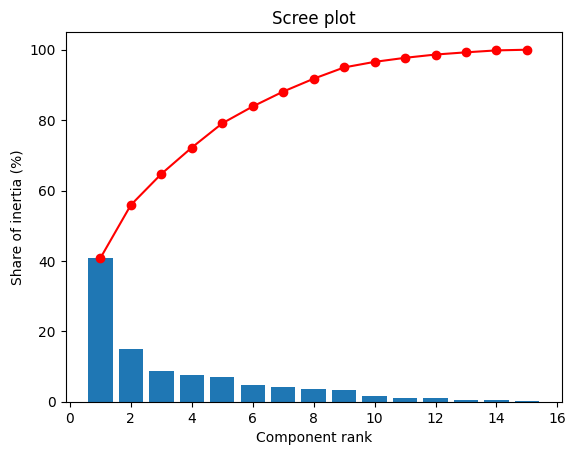

In [9]:
# Scree plot
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum, c="red", marker="o")
plt.xlabel("Component rank")
plt.ylabel("Share of inertia (%)")
plt.title("Scree plot")
plt.show(block=False)

The scree plot visually confirms the reduction from 15 variables to 5 components. Following the elbow criterion, there is a slight visual break between F5 and F6 that justifies keeping 5. We can also see that the cumulative share of inertia reaches 80% at F5.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.2 - Reduced PCA (5 components)</h3>
</div>

In [10]:
# PCA with 5 components only
n_components = 5
pca5 = PCA(n_components=n_components)
pca5.fit(df_acp)
print(f"Number of components: {n_components}")
print(f"Total explained variance: {pca5.explained_variance_ratio_.sum()*100:.2f} %")

Number of components: 5
Total explained variance: 79.09 %


In [11]:
# Check that 79% of the variance comes from 5 components
n1 = pca5.explained_variance_ratio_.sum().round(2)
xpca = PCA(n1)
xpca = xpca.fit_transform(df_acp)
xpca.shape

(164, 5)

Across 164 countries, we reduced 15 variables to 5 principal components.

In [12]:
# Variable loadings on the components
coords = pca5.components_.T * np.sqrt(pca5.explained_variance_)

In [13]:
# Loadings table
df_coords = pd.DataFrame(
    coords, columns=[f"F{i+1}" for i in range(n_components)], index=df_acp.columns
)
df_coords.round(2)

,F1,F2,F3,F4,F5
CC,0.91,-0.18,-0.09,0.00,0.17
PV,0.78,-0.45,-0.19,-0.03,0.04
Internet,0.87,0.01,0.14,0.01,-0.07
Chomage,-0.01,-0.29,0.70,0.06,-0.39
Evolution tourisme,-0.06,0.00,-0.41,0.77,-0.22
LPI,0.88,0.26,-0.06,0.03,0.17
Distance capitale,-0.24,-0.07,-0.61,-0.52,-0.37
RL,0.93,-0.17,-0.08,-0.00,0.20
RQ,0.94,-0.02,-0.07,0.03,0.17
Evolution population,-0.58,-0.00,-0.17,-0.19,0.53


<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.3 - Correlation circles</h3>
</div>

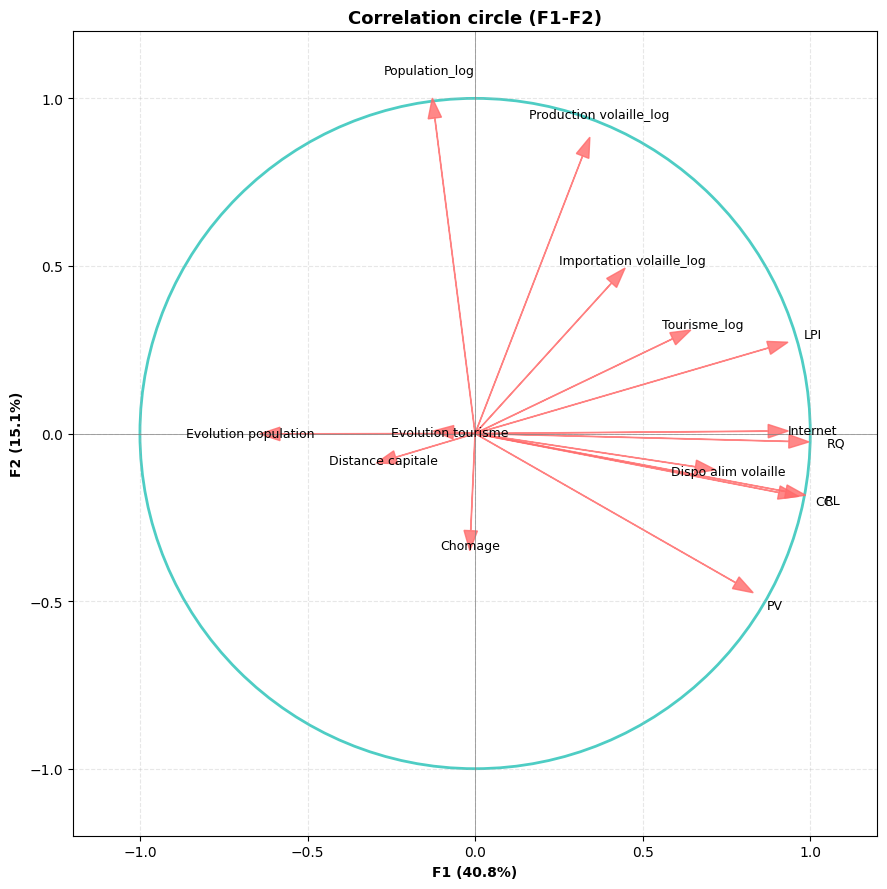

In [14]:
# Correlation circle for F1 and F2
fig, ax = plt.subplots(figsize=(9, 9))

circle = plt.Circle((0, 0), 1, color="#4ECDC4", fill=False, linewidth=2)
ax.add_artist(circle)

for i, var in enumerate(df_acp.columns):
    x, y = coords[i, 0], coords[i, 1]
    ax.arrow(0, 0, x, y, head_width=0.04, color="#FF6B6B", alpha=0.8)
    ax.text(x * 1.15, y * 1.15, var, fontsize=9, ha="center", va="center")


ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")

# Labels
ax.set_xlabel(f"F1 ({pca5.explained_variance_ratio_[0]*100:.1f}%)", fontweight="bold")
ax.set_ylabel(f"F2 ({pca5.explained_variance_ratio_[1]*100:.1f}%)", fontweight="bold")
ax.set_title("Correlation circle (F1-F2)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

The F1-F2 correlation circle alone captures 55.9% of the total variance. It reveals the structure of the first two components:
 - On the positive side, F1 (40.8%) is driven by a group of strongly correlated variables pointing to the right and almost touching the circle: the governance indices (CC, RL, RQ, PV), the Logistics Performance Index, internet access, poultry supply per person and the number of tourists. No coefficient falls below 0.59.
 - On the negative side of F1, population growth (-0.58) characterises countries with fast demographic growth, generally developing countries.
 F1 is therefore an axis of institutional and infrastructure development, opposing developed economies to developing countries with dynamic demographics.
 - F2 (15.1%) is dominated on the positive side by poultry imports (0.45), poultry production (0.83) and population (0.94). On the negative side is political stability (-0.45).
 F2 sets a country's demographic weight against its political stability: small stable countries versus large, less stable ones.
 Variables close to the centre, or poorly represented, will probably bring additional information on the next plane.

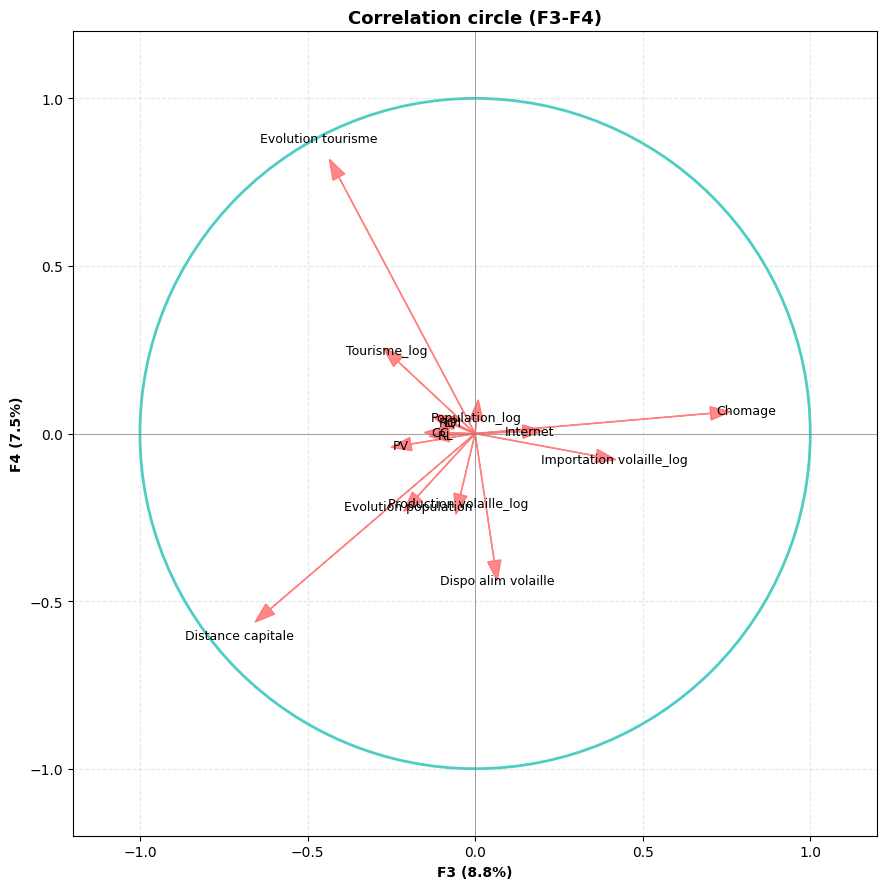

In [15]:
# Correlation circle for F3 and F4
fig, ax = plt.subplots(figsize=(9, 9))

circle = plt.Circle((0, 0), 1, color="#4ECDC4", fill=False, linewidth=2)
ax.add_artist(circle)

for i, var in enumerate(df_acp.columns):
    x, y = coords[i, 2], coords[i, 3]
    ax.arrow(0, 0, x, y, head_width=0.04, color="#FF6B6B", alpha=0.8)
    ax.text(x * 1.15, y * 1.15, var, fontsize=9, ha="center", va="center")


ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")


ax.set_xlabel(f"F3 ({pca5.explained_variance_ratio_[2]*100:.1f}%)", fontweight="bold")
ax.set_ylabel(f"F4 ({pca5.explained_variance_ratio_[3]*100:.1f}%)", fontweight="bold")
ax.set_title("Correlation circle (F3-F4)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

The F3-F4 plane, which captures an additional 16.3% of the variance, completes the picture by revealing three key variables that were poorly represented on F1-F2:
 - On the positive side of F3 (8.8%) is unemployment (0.70); on the negative side, tourism growth (-0.41) and distance from Paris (-0.61).
 F3 separates countries geographically close to France with high unemployment from more distant countries with dynamic tourism.
 - F4 (7.5%) has one positive variable, tourism growth (0.77), and one negative variable, distance from Paris (-0.52).
 F4 is a synthetic axis that combines two independent pieces of information, tourism growth and geographic proximity. It separates countries that both have growing tourism and are close to France from the others. However, F4 does not reflect any direct relationship between the two variables (see the correlation matrix): it captures a specific combination of these two dimensions.

F5 (6.89%) is our last component and mainly captures population growth (0.52 in the loadings table). F5 therefore isolates a pure demographic signal, independent from the level of development. This dimension remains minor and does not require a dedicated visualisation.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 3 - Projecting the countries</h2>
</div>

In [16]:
# Project the countries into the PCA space
X_proj = pca5.transform(df_acp)

# DataFrame with the country coordinates
df_proj = pd.DataFrame(
    X_proj, columns=[f"F{i+1}" for i in range(n_components)], index=df_acp.index
)

df_proj.head()

,F1,F2,F3,F4,F5
Name,,,,,
Afghanistan,-5.448724,0.462671,1.870175,-0.824656,1.128984
Albania,0.148558,-0.953464,0.889789,2.361691,-1.092663
Algeria,-2.052213,0.724609,0.942361,0.688602,-0.129918
Angola,-3.159405,0.526790,1.769997,-0.767747,0.163075
Argentina,0.602953,1.007362,-0.750133,-1.326580,-1.640049


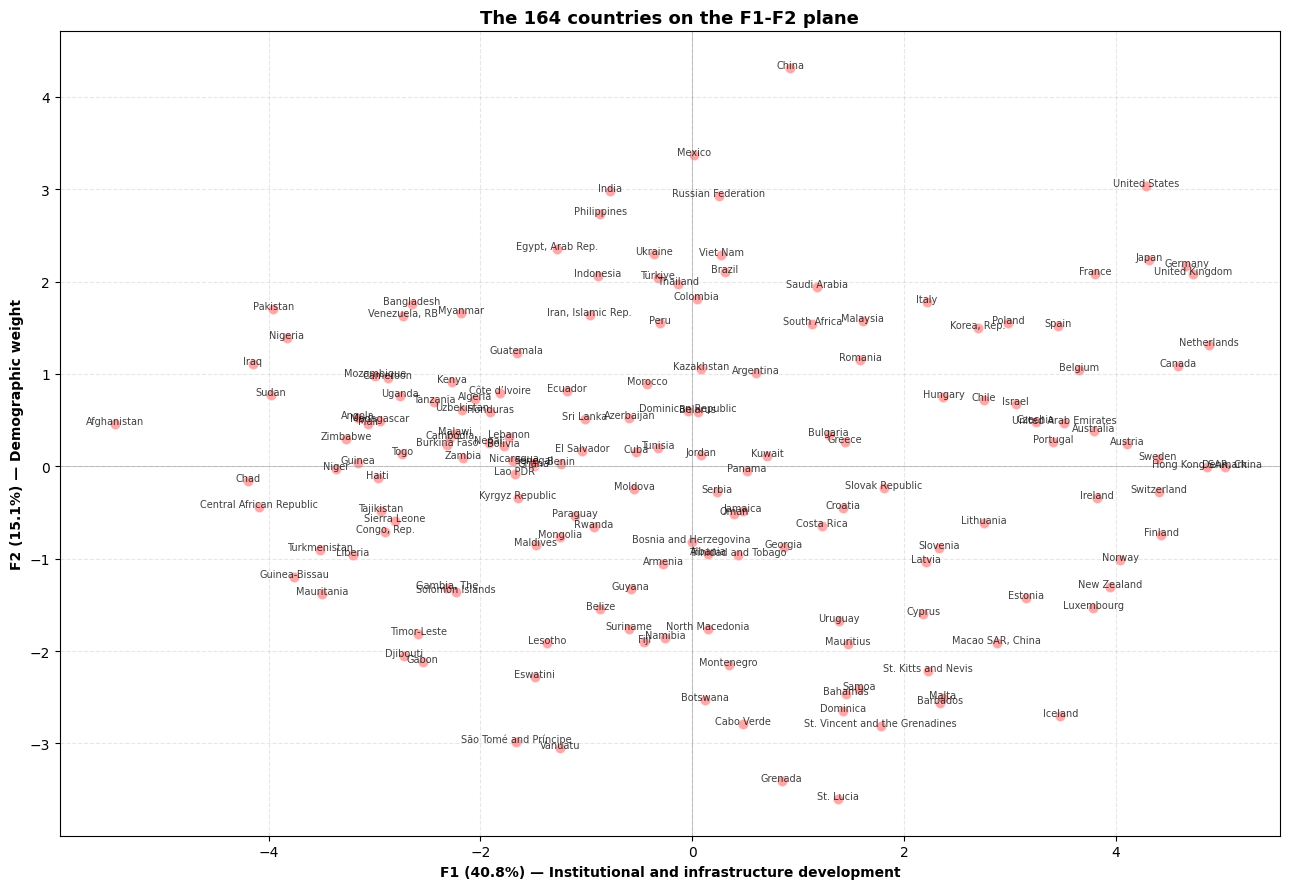

In [17]:
# Scatter plot on F1-F2
fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(
    df_proj["F1"],
    df_proj["F2"],
    alpha=0.6,
    color="#FF6B6B",
    s=60,
    edgecolors="white",
    linewidth=1,
)

for pays in df_proj.index:
    ax.annotate(
        pays,
        (df_proj.loc[pays, "F1"], df_proj.loc[pays, "F2"]),
        fontsize=7,
        alpha=0.75,
        ha="center",
    )

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)

ax.set_xlabel(
    f"F1 ({pca5.explained_variance_ratio_[0]*100:.1f}%) — Institutional and infrastructure development",
    fontweight="bold",
)
ax.set_ylabel(
    f"F2 ({pca5.explained_variance_ratio_[1]*100:.1f}%) — Demographic weight",
    fontweight="bold",
)
ax.set_title(
    "The 164 countries on the F1-F2 plane", fontsize=13, fontweight="bold"
)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Projecting the 164 countries onto the F1-F2 plane (55.9%) reveals several natural groupings:
 - F1+, F2+: large developed economies, such as the USA, France, Japan, Germany and Canada.
 - F1-, F2+: developing demographic giants, such as India, Indonesia, Bangladesh, Nigeria and Egypt.
 - F1+, F2-: small, highly developed countries (most of them islands), such as Switzerland, Finland, Norway, Macao and Luxembourg.
 - F1-, F2-: small, highly vulnerable countries with low population and low development, such as Chad, Liberia, Guinea-Bissau and Gabon.

China stands out very high on F2 because of its huge population. Afghanistan is isolated on the left as the least developed country according to our indicators.

This distribution already suggests four groups of countries; the F3-F4 plane will complete the picture.

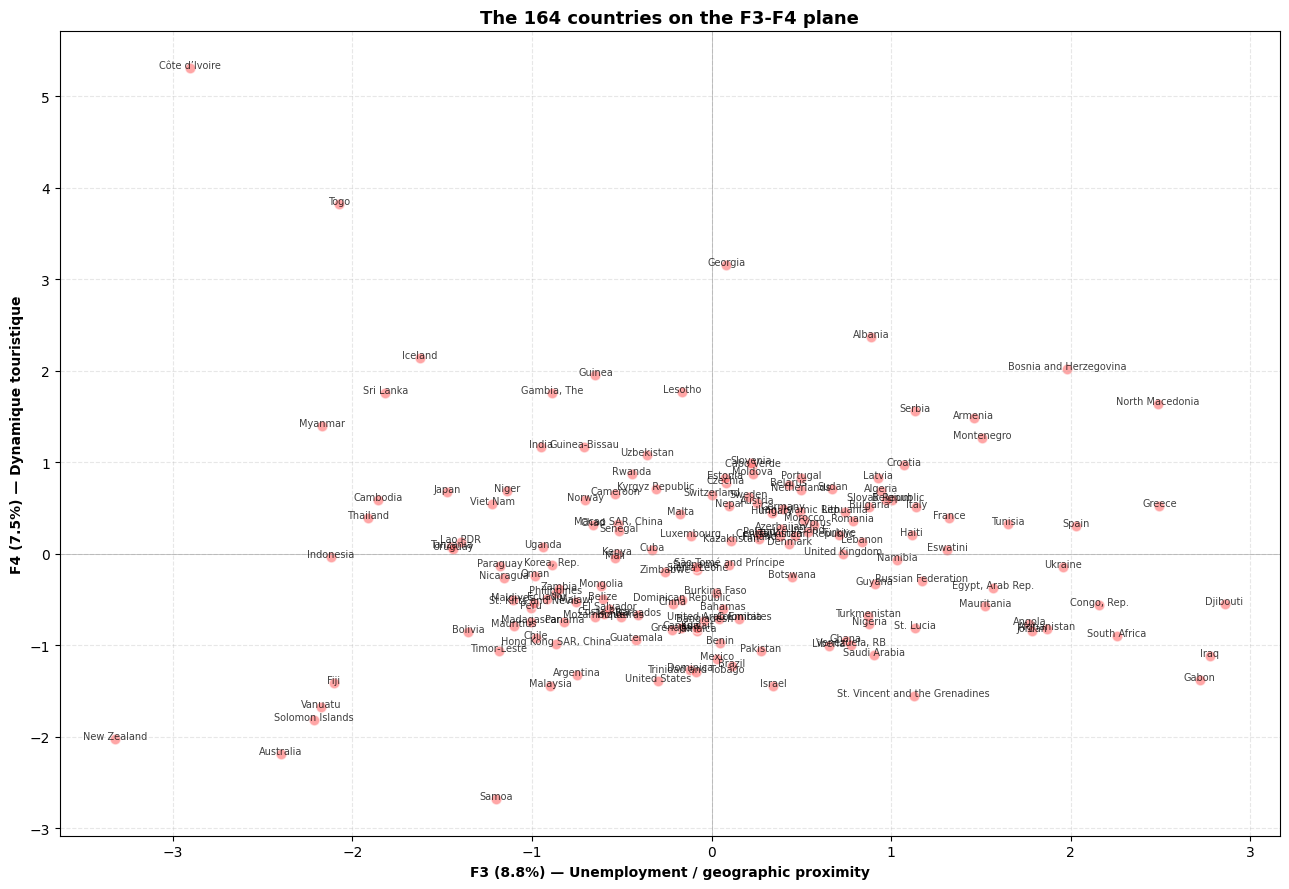

In [18]:
# Scatter plot on F3-F4
fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(
    df_proj["F3"],
    df_proj["F4"],
    alpha=0.6,
    color="#FF6B6B",
    s=60,
    edgecolors="white",
    linewidth=1,
)

for pays in df_proj.index:
    ax.annotate(
        pays,
        (df_proj.loc[pays, "F3"], df_proj.loc[pays, "F4"]),
        fontsize=7,
        alpha=0.75,
        ha="center",
    )

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)

ax.set_xlabel(
    f"F3 ({pca5.explained_variance_ratio_[2]*100:.1f}%) — Unemployment / geographic proximity",
    fontweight="bold",
)
ax.set_ylabel(
    f"F4 ({pca5.explained_variance_ratio_[3]*100:.1f}%) — Dynamique touristique",
    fontweight="bold",
)
ax.set_title(
    "The 164 countries on the F3-F4 plane", fontsize=13, fontweight="bold"
)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

The second factorial plane, F3-F4, captures more specific and nuanced information (about 16% of the total). It acts as a magnifying glass on dynamics that were not visible on the first plane:
 - F3 groups countries by labour-market dynamics or geographic blocks. It isolates Oceania in the bottom left (Australia, Vanuatu, New Zealand), and countries with high unemployment or far away on the right (Djibouti, Gabon, South Africa).
 - F4 captures tourism dynamics and attractiveness. At the top are countries with strong recent tourism growth (Albania, Georgia); at the bottom, countries with more mature, slower-growing tourism (USA, Argentina, Malaysia).
 - This plane also highlights outliers such as Côte d'Ivoire, Togo and Samoa, which stand apart with very distinct tourism profiles.

The principal component analysis reduced our 15 variables to 5 principal components, keeping 79.1% of the original information. The correlation circles and the country projections reveal natural groupings that fully justify a clustering approach.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 4 - Clustering</h2>
</div>

After reducing dimensionality with the PCA, we group the countries into homogeneous clusters. We proceed in two stages: a hierarchical clustering (Ward's method) to determine the optimal number of groups from the dendrogram, then a k-means to refine and stabilise these groups. The clustering is performed on the 5 principal components, which summarise 79.1% of the total information.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.1 - Hierarchical clustering</h3>
</div>

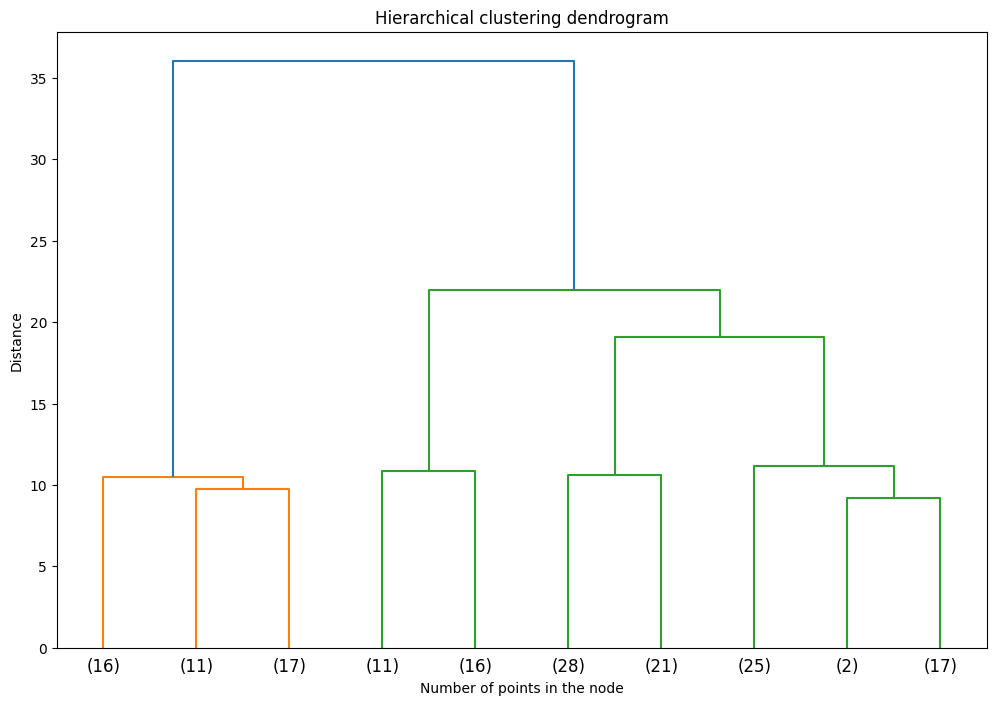

In [19]:
# Dendrogram
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
Z = linkage(df_proj, method="ward")
_ = dendrogram(Z, p=10, truncate_mode="lastp", ax=ax)
plt.title("Hierarchical clustering dendrogram")
plt.xlabel("Number of points in the node")
plt.ylabel("Distance")
plt.show()

The truncated dendrogram shows the last 10 merges for readability. The largest jump in distance, between 22 and 36, would isolate two large blocks, which is too coarse a segmentation. We therefore cut at 15, which gives 4 usable clusters, to be confirmed with the elbow method and the silhouette score.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.2 - Elbow method</h3>
</div>

In [20]:
# Test several values of K
inerties = []
silhouettes = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(df_proj)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(df_proj, lab))

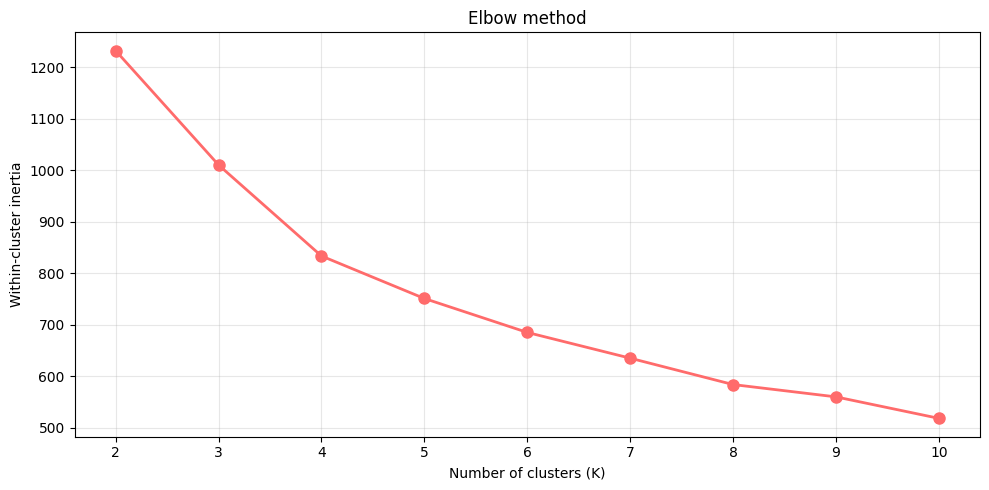

In [21]:
# Elbow chart
plt.figure(figsize=(10, 5))
plt.plot(ks, inerties, "o-", color="#FF6B6B", linewidth=2, markersize=8)
plt.title("Elbow method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-cluster inertia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The elbow method looks at how the within-cluster inertia evolves with the number of clusters. We look for the elbow of the curve, the point beyond which adding a cluster only brings a marginal gain. The chart shows a break around K = 3-4; beyond that, the gain in inertia becomes marginal.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.3 - Silhouette score</h3>
</div>

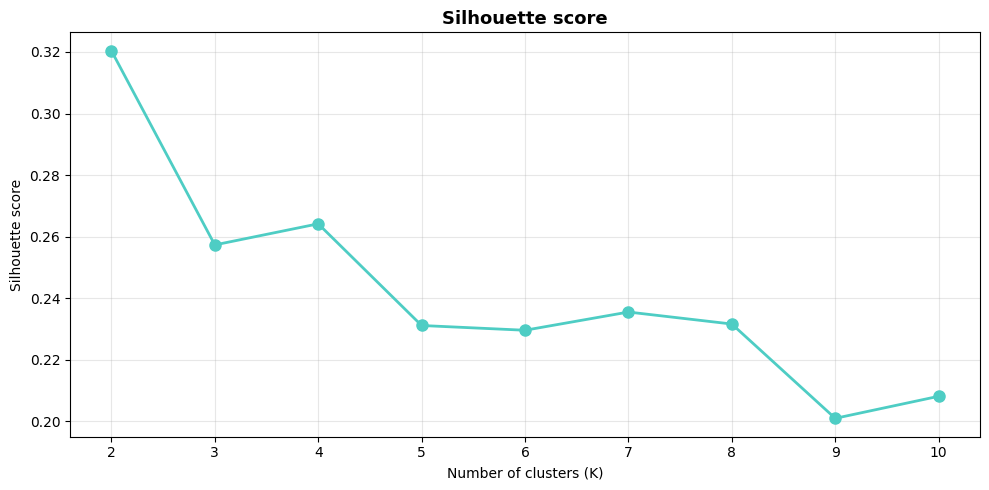

In [22]:
# Silhouette score
plt.figure(figsize=(10, 5))
plt.plot(ks, silhouettes, "o-", color="#4ECDC4", linewidth=2, markersize=8)
plt.title("Silhouette score", fontsize=13, fontweight="bold")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The silhouette score measures how well the clusters are separated: it evaluates how close each country is to its own cluster compared with neighbouring clusters. The closer the score is to 1, the better the partition. Here the highest score is 0.32 for K = 2, but as noted with the hierarchical clustering, a segmentation into only two groups would be too coarse to be useful. The second peak (about 0.26) gives K = 4, in line with the elbow method and the dendrogram.

Our three approaches converge on K = 4, so we can now run the k-means algorithm with this number of clusters to obtain a stable partition of our 164 countries.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.4 - K-means</h3>
</div>

In [23]:
# List of components ACP
compo_acp = ["F1", "F2", "F3", "F4", "F5"]

In [24]:
# K-means with 4 clusters
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans4.fit(df_proj[compo_acp])
labels4 = kmeans4.labels_

In [25]:
# Store the centroids
centroids = kmeans4.cluster_centers_

In [26]:
# Assign each country its cluster
df_volaille_final["cluster_4"] = labels4
df_proj["cluster_4"] = labels4
print("Countries per cluster:")
print(df_volaille_final["cluster_4"].value_counts().sort_index())

Countries per cluster:
cluster_4
0    38
1    35
2    35
3    56
Name: count, dtype: int64


In [27]:
# K-means with 5 clusters (robustness check)
kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans5.fit(df_proj[compo_acp])
labels5 = kmeans5.labels_
df_volaille_final["cluster_5"] = labels5
print(df_volaille_final["cluster_5"].value_counts().sort_index())

cluster_5
0    33
1    39
2    34
3    35
4    23
Name: count, dtype: int64


The parameter random_state=42 fixes the random seed to make the results reproducible. The parameter n_init=10 runs the algorithm 10 times with different initialisations and keeps only the best partition, the one that minimises within-cluster inertia, which makes the clustering more robust.

In [28]:
# Contingency table, 4 vs 5 clusters
comparaison = pd.crosstab(
    df_volaille_final["cluster_4"], df_volaille_final["cluster_5"]
)
comparaison

cluster_5,0,1,2,3,4
cluster_4,,,,,
0,32,5,0,0,1
1,0,0,0,35,0
2,1,0,34,0,0
3,0,34,0,0,22


After studying the contingency table crossing the results for k = 4 and k = 5, the decision to keep 4 clusters is final. Clusters 0, 1 and 2 prove extremely stable, with almost all of their countries keeping the same membership, which confirms the robustness of these groups. The 5-cluster segmentation simply splits cluster 3 (k = 4) into two groups and adds no useful information.

In [29]:
# PESTEL variables
var_acp_brutes = [
    "CC",
    "PV",
    "Internet",
    "Chomage",
    "Evolution tourisme",
    "LPI",
    "Distance capitale",
    "RL",
    "RQ",
    "Evolution population",
    "Dispo alim volaille",
    "Tourisme",
    "Population",
    "Production volaille",
    "Importation volaille",
]

To make the business interpretation of the clusters easier, we use the variables in their raw form, before any transformation.

In [30]:
# Average profile of each cluster on the original variables
profil = df_volaille_final.groupby("cluster_4")[var_acp_brutes].mean().round(2)
profil

,CC,PV,Internet,Chomage,Evolution tourisme,LPI,Distance capitale,RL,RQ,Evolution population,Dispo alim volaille,Tourisme,Population,Production volaille,Importation volaille
cluster_4,,,,,,,,,,,,,,,
0,39.18,58.30,59.57,7.12,69.09,2.88,6294.26,49.28,52.47,4.18,8.04,16810342.11,121378.03,1894.95,135.03
1,53.30,73.68,59.43,11.82,77.62,2.72,6567.17,61.39,57.71,2.35,9.55,3600045.71,1693.64,38.81,17.76
2,75.04,79.38,86.26,5.82,55.57,3.70,3537.17,79.66,76.85,2.22,10.91,35133021.43,31243.58,1242.39,213.39
3,30.24,54.30,27.14,6.28,72.20,2.48,6300.62,42.76,43.82,10.37,2.39,1084555.36,25348.42,93.48,37.45


In [31]:
# List of countries per cluster
for k in range(4):
    pays = df_volaille_final[df_volaille_final["cluster_4"] == k]["Name"].tolist()
    print(f"\n=== Cluster {k} ({len(pays)} countries) ===")
    print(", ".join(pays))


=== Cluster 0 (38 countries) ===
Argentina, Azerbaijan, Belarus, Brazil, Bulgaria, China, Colombia, Cuba, Dominican Republic, Ecuador, Egypt, Arab Rep., El Salvador, Greece, India, Indonesia, Iran, Islamic Rep., Jordan, Kazakhstan, Kuwait, Malaysia, Mexico, Moldova, Morocco, Myanmar, Panama, Peru, Philippines, Romania, Russian Federation, Saudi Arabia, South Africa, Sri Lanka, Thailand, Tunisia, Türkiye, Ukraine, Venezuela, RB, Viet Nam

=== Cluster 1 (35 countries) ===
Albania, Armenia, Bahamas, Barbados, Belize, Bosnia and Herzegovina, Botswana, Cabo Verde, Costa Rica, Croatia, Cyprus, Dominica, Eswatini, Fiji, Georgia, Grenada, Guyana, Jamaica, Latvia, Lesotho, Malta, Mauritius, Montenegro, Namibia, North Macedonia, Samoa, São Tomé and Príncipe, Serbia, St. Kitts and Nevis, St. Lucia, St. Vincent and the Grenadines, Suriname, Trinidad and Tobago, Uruguay, Vanuatu

=== Cluster 2 (35 countries) ===
Australia, Austria, Belgium, Canada, Chile, Czechia, Denmark, Estonia, Finland, France

- Cluster 0 - Large emerging economies (38 countries): China, Colombia, Brazil, Egypt, India. Highly populated, fast-developing countries with already significant poultry production.
  - Cluster 1 - Small middle-income countries (35 countries): many are island states, which makes them harder and more expensive to reach. Modest economies, mainly driven by tourism.
  - Cluster 2 - Developed economies (35 countries): France, the USA, Germany, Belgium, Italy. The largest poultry importers, the second-largest producers, the highest poultry supply per person, the best governance indices, and the most developed infrastructure, technology and logistics. This cluster also has the most tourism of all four and is the closest to France. With the best score on 12 of the 15 original variables, it stands out as the main export target.
  - Cluster 3 - Developing countries (56 countries), the largest cluster: countries with fast population growth, mostly in Africa and the Middle East. The lowest poultry supply per person of all clusters, and close to the lowest poultry production and imports.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.5 - Visualising the clusters</h3>
</div>

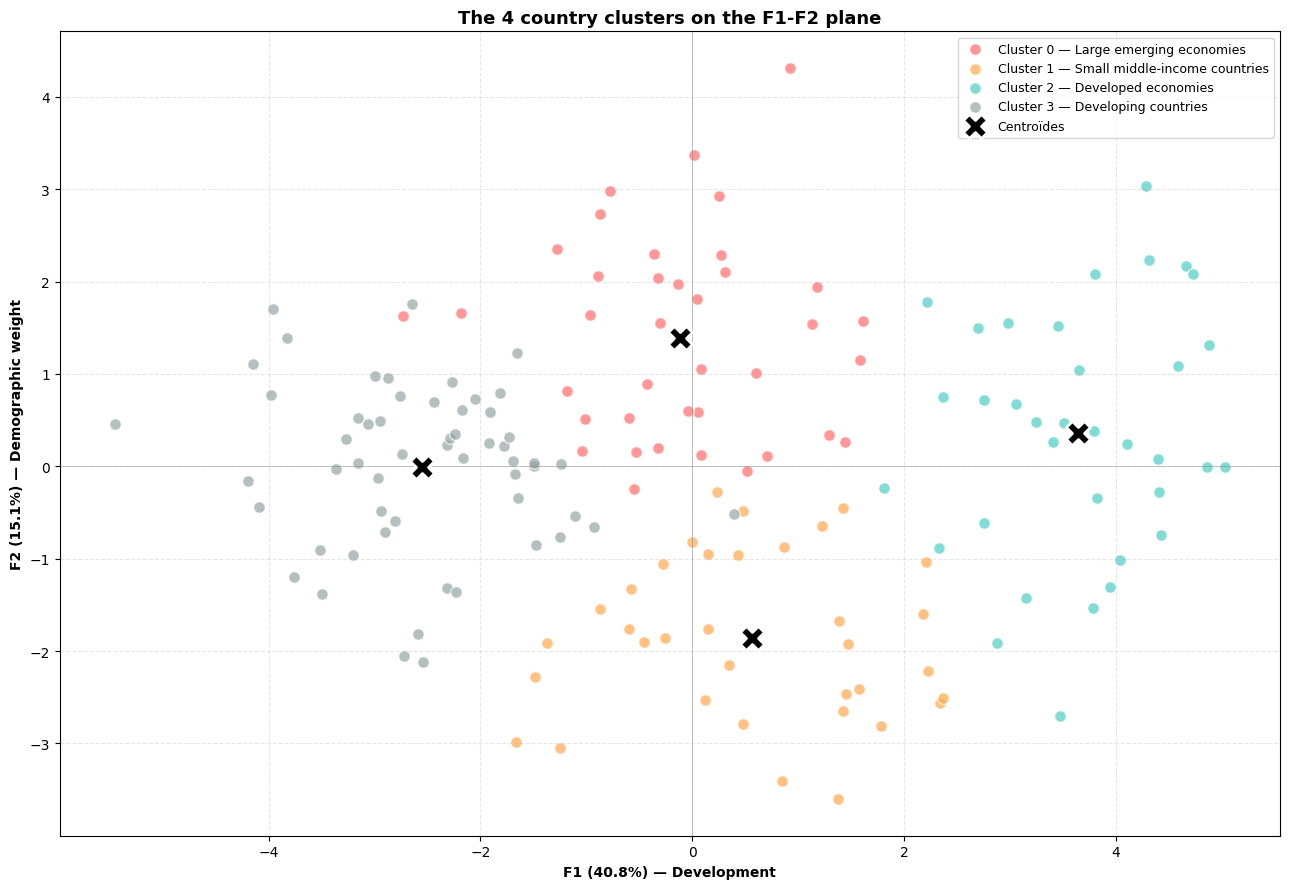

In [32]:
# Clusters on the F1-F2 plane
fig, ax = plt.subplots(figsize=(13, 9))

cluster_names = {
    0: "Large emerging economies",
    1: "Small middle-income countries",
    2: "Developed economies",
    3: "Developing countries",
}
colors = ["#FF6B6B", "#FFA94D", "#4ECDC4", "#95A5A6"]

for k in range(4):
    mask = df_proj["cluster_4"] == k
    ax.scatter(
        df_proj.loc[mask, "F1"],
        df_proj.loc[mask, "F2"],
        c=colors[k],
        label=f"Cluster {k} — {cluster_names[k]}",
        alpha=0.7,
        s=70,
        edgecolors="white",
        linewidth=1,
    )

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    marker="X",
    s=300,
    edgecolors="white",
    linewidth=2,
    label="Centroïdes",
    zorder=5,
)

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.set_xlabel(
    f"F1 ({pca5.explained_variance_ratio_[0]*100:.1f}%) — Development",
    fontweight="bold",
)
ax.set_ylabel(
    f"F2 ({pca5.explained_variance_ratio_[1]*100:.1f}%) — Demographic weight",
    fontweight="bold",
)
ax.set_title("The 4 country clusters on the F1-F2 plane", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Projecting the clusters onto the F1-F2 plane confirms the quality of our segmentation, with 4 groups occupying distinct areas of the factorial space.
Cluster 3 is concentrated on the left, where F1 is low, meaning a low level of institutional and infrastructure development.
Cluster 2 sits clearly on the right of the plane, gathering the countries with the best governance, infrastructure and internet access.
Cluster 0 occupies the top of the chart: large populations with emerging economies.
Cluster 1 sits at the bottom: countries with small populations and limited development.
The centroids (black crosses) mark the centre of gravity of each group and confirm this separation.

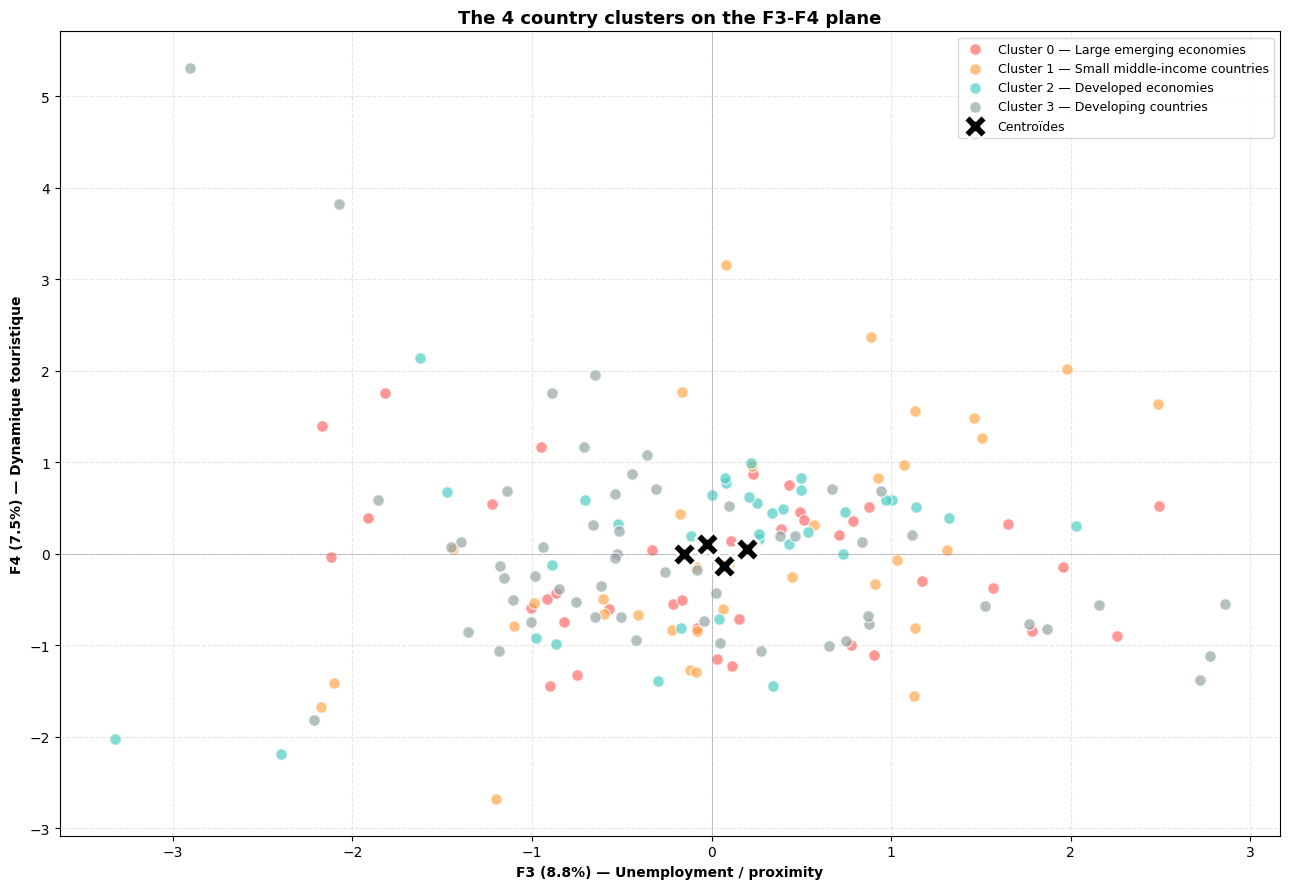

In [33]:
# Clusters on the F3-F4 plane
fig, ax = plt.subplots(figsize=(13, 9))

cluster_names = {
    0: "Large emerging economies",
    1: "Small middle-income countries",
    2: "Developed economies",
    3: "Developing countries",
}
colors = ["#FF6B6B", "#FFA94D", "#4ECDC4", "#95A5A6"]

for k in range(4):
    mask = df_proj["cluster_4"] == k
    ax.scatter(
        df_proj.loc[mask, "F3"],
        df_proj.loc[mask, "F4"],
        c=colors[k],
        label=f"Cluster {k} — {cluster_names[k]}",
        alpha=0.7,
        s=70,
        edgecolors="white",
        linewidth=1,
    )

ax.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c="black",
    marker="X",
    s=300,
    edgecolors="white",
    linewidth=2,
    label="Centroïdes",
    zorder=5,
)

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.set_xlabel(
    f"F3 ({pca5.explained_variance_ratio_[2]*100:.1f}%) — Unemployment / proximity",
    fontweight="bold",
)
ax.set_ylabel(
    f"F4 ({pca5.explained_variance_ratio_[3]*100:.1f}%) — Dynamique touristique",
    fontweight="bold",
)
ax.set_title("The 4 country clusters on the F3-F4 plane", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

On the F3-F4 plane, the 4 clusters overlap heavily and their centroids are all concentrated around the origin. This was expected, since the clusters are separated mainly along F1-F2, while F3-F4 captures only 16% of the total variance.
This plane confirms that our groups differ above all by their level of development and their demographic size, rather than by their tourism dynamics or unemployment level.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 5 - Mapping the clusters</h2>
</div>

In [34]:
# Update Turkey's name for the map
df_volaille_final["Name"] = df_volaille_final["Name"].replace("Türkiye", "Turkey")

In [35]:
# World map of the clusters
df_carte = df_volaille_final[["Name", "cluster_4"]].copy()

cluster_names = {
    0: "Large emerging economies",
    1: "Small middle-income countries",
    2: "Developed economies",
    3: "Developing countries",
}
df_carte["Groupe"] = df_carte["cluster_4"].map(cluster_names)

color_map = {
    "Large emerging economies": "#FF6B6B",
    "Small middle-income countries": "#FFA94D",
    "Developed economies": "#4ECDC4",
    "Developing countries": "#95A5A6",
}

fig = px.choropleth(
    df_carte,
    locations="Name",
    locationmode="country names",
    color="Groupe",
    hover_name="Name",
    color_discrete_map=color_map,
    projection="natural earth",
    title="World segmentation of the 164 countries by cluster",
)

fig.update_layout(
    title=dict(
        text="World segmentation of the 164 countries by cluster", x=0.5, font=dict(size=18)
    ),
    width=1400,
    height=800,
    legend=dict(
        title="Clusters",
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        x=0.5,
        xanchor="center",
        font=dict(size=12),
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        showcountries=True,
        countrycolor="lightgray",
        showocean=True,
        oceancolor="#f0f8ff",
        showland=True,
        landcolor="#f5f5f5",
    ),
)

fig.show()

This choropleth map gives a geographic view of our 164 countries segmented into 4 clusters. It is the last step of our market study, as it shows which geographic areas to target.
The developed economies (turquoise) were identified earlier as the best target for exporting poultry abroad. They combine proximity to France, political stability and easy logistics, which greatly facilitates opening export markets. They are also large markets with the highest poultry supply per person. This cluster covers most of Europe, the USA and Canada, and Australia and Japan.
Europe and North America therefore appear to be the best areas to target for La poule qui chante's international expansion.